# Big Data Assighnment 

Student Name : Hetha Putane , Student Number : 23373726

Task 5: Genre – Box Office Correlation

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import ast 
import time
import tracemalloc
from itertools import combinations

Reading in Dataset

In [6]:
df = pd.read_csv("movies_cleaned.csv")
df.head(5)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,imdb_id,...,director_count,main_director,has_director,good_director_data,missing_writers,has_multiple_writers,writers_count,main_writer,has_writers,good_writers_data
0,2,Ariel,7.1,367,Released,1988-10-21,0,73,0,tt0094675,...,1,Aki Kaurismäki,True,True,False,False,1,Aki Kaurismäki,True,True
1,3,Shadows in Paradise,7.3,430,Released,1986-10-17,0,74,0,tt0092149,...,1,Aki Kaurismäki,True,True,False,False,1,Aki Kaurismäki,True,True
2,5,Four Rooms,5.9,2780,Released,1995-12-09,4257354,98,4000000,tt0113101,...,4,Alexandre Rockwell,True,True,False,True,4,Allison Anders,True,True
3,6,Judgment Night,6.5,360,Released,1993-10-15,12136938,109,21000000,tt0107286,...,1,Stephen Hopkins,True,True,False,True,2,Lewis Colick,True,True
4,9,Sunday in August,6.8,28,Released,2004-09-02,0,15,0,tt0425473,...,1,Marc Meyer,True,True,False,False,1,Marc Meyer,True,True


## Task 5: Genre – Box Office Correlation

I am  basically cleaning the genres column so i can carry out conducting the qeuries. 
There was a problem when with the genre list column it was printing out as a list but in a string, Like for example it printed out "['Thriller', 'Drama', 'Comedy']" instead of ['Thriller', 'Drama', 'Comedy'] like without the double qoutes 

In [9]:
df = df[df["revenue"] > 0].copy()

def fix_genres(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)          # turns "['Comedy','Drama']" into ['Comedy','Drama']
            return v if isinstance(v, list) else []
        except:
            return []
    return []

df["genres_fixed"] = df["genres_list"].apply(fix_genres)

df_exploded = (
    df.explode("genres_fixed")
      .rename(columns={"genres_fixed": "genre"})
)
df_exploded = df_exploded[df_exploded["genre"].notna() & (df_exploded["genre"] != "")].copy()

# should be plain strings like 'Comedy'
print(df_exploded["genre"].head(10).tolist())

['Comedy', 'Action', 'Crime', 'Thriller', 'Adventure', 'Action', 'Science Fiction', 'Animation', 'Family', 'Comedy']


btw guys remember that explode() transforms a list-like column so that each element in the list becomes its own separate row, duplicating the other column values accordingly.

## <span style="color:blue">Q1. Average revenue by genre </span>

In [12]:
from IPython.display import display

tracemalloc.start()
start = time.perf_counter()

q1 = (
    df_exploded
    .groupby("genre", as_index=False)
    .agg(
        movie_count=("revenue", "size"),
        avg_revenue=("revenue", "mean")
    )
    .sort_values(["avg_revenue", "movie_count"], ascending=[False, False])
)

end = time.perf_counter()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

q1["avg_revenue"] = q1["avg_revenue"].round(2)

display(q1.head(15))
print(f"Execution Time: {end-start:.4f} sec")
print(f"Peak Memory: {peak/1e6:.2f} MB")

,genre,movie_count,avg_revenue
1,Adventure,3013,1.082988e+08
14,Science Fiction,1847,9.150141e+07
8,Fantasy,2024,7.637935e+07
0,Action,4429,7.458830e+07
7,Family,2190,7.255546e+07
2,Animation,1621,7.249486e+07
17,War,742,3.767925e+07
16,Thriller,4692,3.598787e+07
3,Comedy,8454,3.373166e+07
4,Crime,3009,3.207581e+07


Execution Time: 0.0111 sec
Peak Memory: 3.04 MB


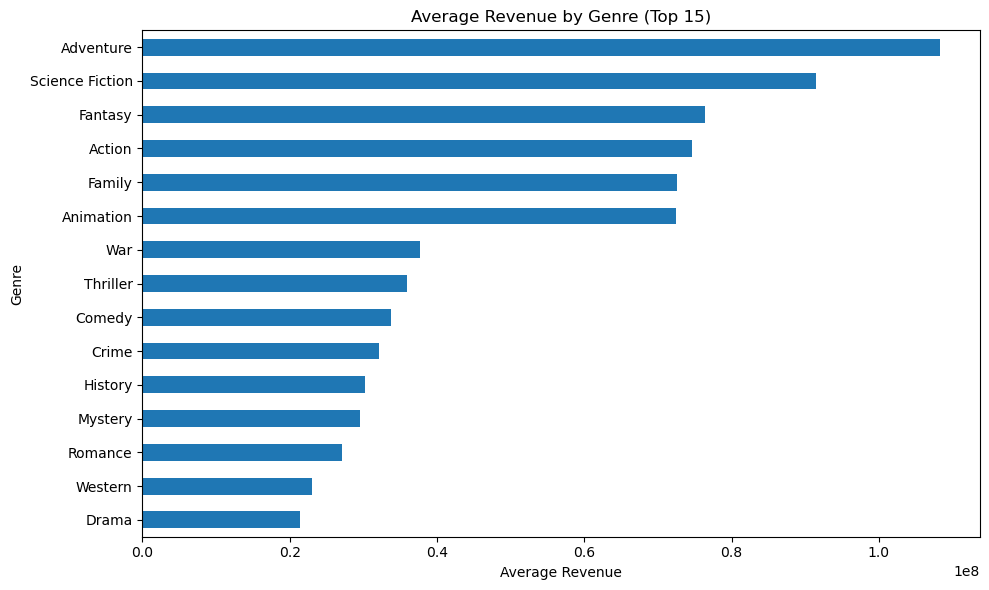

In [13]:
# Top N keeps it readable . The N is the first 15 rows of the dataset . I just used 15 because its readable and doesnt need so many lines 
TOP_N = 15

q1 = (
    df_exploded.groupby("genre")["revenue"]
    .mean()
    .sort_values(ascending=False)
    .head(TOP_N)
)

plt.figure(figsize=(10, 6))
q1.sort_values().plot(kind="barh")  # smallest at bottom, biggest at top
plt.title(f"Average Revenue by Genre (Top {TOP_N})")
plt.xlabel("Average Revenue")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

## <span style="color:blue">Q2. Revenue Distribution per Genre</span>

In [15]:
tracemalloc.start()
start = time.perf_counter()

q2 = (
    df_exploded
    .groupby("genre")
    .agg(
        movie_count=("revenue","size"),
        mean=("revenue","mean"),
        median=("revenue","median"),
        std=("revenue","std"),
        min=("revenue","min"),
        q1=("revenue", lambda s: s.quantile(0.25)),
        q3=("revenue", lambda s: s.quantile(0.75)),
        max=("revenue","max"),
    )
    .reset_index()
)

q2["iqr"] = q2["q3"] - q2["q1"]
q2 = q2.sort_values(["mean","movie_count"], ascending=[False, False])

end = time.perf_counter()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

for c in ["mean","median","std","min","q1","q3","max","iqr"]:
    q2[c] = q2[c].round(2)

display(q2.head(15))
print(f"Execution Time: {end-start:.4f} sec")
print(f"Peak Memory: {peak/1e6:.2f} MB")

,genre,movie_count,mean,median,std,min,q1,q3,max,iqr
1,Adventure,3013,1.082988e+08,13380561.0,2.433919e+08,1,1831166.00,84563118.00,2923706026,82731952.00
14,Science Fiction,1847,9.150141e+07,8247943.0,2.346089e+08,1,445864.00,58531226.00,2923706026,58085362.00
8,Fantasy,2024,7.637935e+07,7515898.5,1.949387e+08,1,624683.25,49553594.50,2923706026,48928911.25
0,Action,4429,7.458830e+07,9600000.0,1.887861e+08,1,943339.00,56343000.00,2923706026,55399661.00
7,Family,2190,7.255546e+07,8892052.0,1.735065e+08,1,1000000.00,49966817.00,1744338246,48966817.00
2,Animation,1621,7.249486e+07,6776616.0,1.895789e+08,1,688995.00,37475850.00,2259822417,36786855.00
17,War,742,3.767925e+07,4408684.0,9.364995e+07,1,448160.75,24708752.50,902540935,24260591.75
16,Thriller,4692,3.598787e+07,3704300.0,9.662877e+07,1,212723.25,26776422.25,1671537444,26563699.00
3,Comedy,8454,3.373166e+07,3500518.5,9.761989e+07,1,274913.75,22034131.75,1744338246,21759218.00
4,Crime,3009,3.207581e+07,4900000.0,8.154590e+07,1,381784.00,27900000.00,1515400000,27518216.00


Execution Time: 0.0304 sec
Peak Memory: 3.03 MB


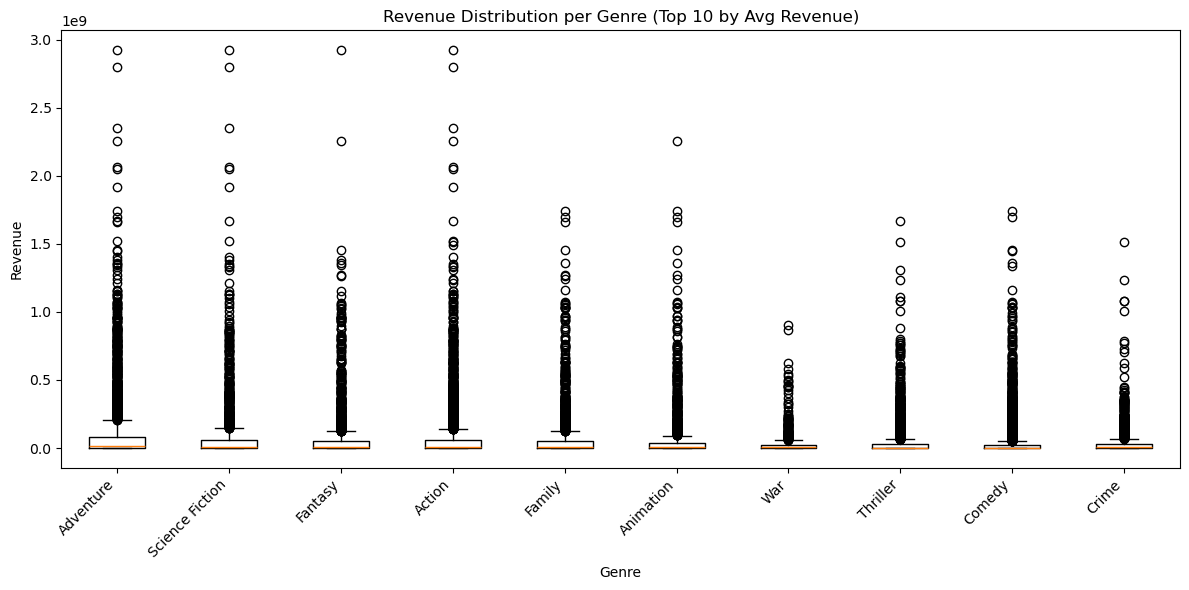

In [32]:
TOP_N = 10

top_genres = (
    df_exploded.groupby("genre")["revenue"]
    .mean()
    .sort_values(ascending=False)
    .head(TOP_N)
    .index
)

data = [df_exploded.loc[df_exploded["genre"] == g, "revenue"].dropna().values for g in top_genres]

plt.figure(figsize=(12, 6))
plt.boxplot(data, labels=list(top_genres), showfliers=True)
plt.title(f"Revenue Distribution per Genre (Top {TOP_N} by Avg Revenue)")
plt.xlabel("Genre")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## <span style="color:blue">Q3. Genre Pair Revenue Analysis</span>

In [17]:
tracemalloc.start()
start = time.perf_counter()

pairs = []
for genres, revenue in zip(df["genres_fixed"], df["revenue"]):
    genres = sorted(set([g for g in genres if pd.notna(g)]))
    if len(genres) > 1:
        for a, b in combinations(genres, 2):
            pairs.append((a, b, revenue))

pairs_df = pd.DataFrame(pairs, columns=["genre_a", "genre_b", "revenue"])

q3 = (
    pairs_df
    .groupby(["genre_a","genre_b"], as_index=False)
    .agg(
        pair_movie_count=("revenue","size"),
        avg_revenue=("revenue","mean"),
        median_revenue=("revenue","median")
    )
    .sort_values(["avg_revenue","pair_movie_count"], ascending=[False, False])
)

end = time.perf_counter()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

q3[["avg_revenue","median_revenue"]] = q3[["avg_revenue","median_revenue"]].round(2)


q3_report = q3[q3["pair_movie_count"] >= 30]

display(q3_report.head(15))
print(f"Execution Time: {end-start:.4f} sec")
print(f"Peak Memory: {peak/1e6:.2f} MB")

,genre_a,genre_b,pair_movie_count,avg_revenue,median_revenue
30,Adventure,Science Fiction,620,1.867832e+08,31222429.0
13,Action,Science Fiction,851,1.513220e+08,18000000.0
0,Action,Adventure,1330,1.455601e+08,22854569.5
24,Adventure,Fantasy,789,1.290247e+08,19748009.0
39,Animation,Family,864,1.155363e+08,16433954.5
7,Action,Fantasy,522,1.145984e+08,16271090.0
35,Animation,Comedy,653,1.137554e+08,10849131.0
18,Adventure,Animation,746,1.065350e+08,16339962.5
32,Adventure,Thriller,383,1.031866e+08,28000000.0
23,Adventure,Family,995,1.020209e+08,18315000.0


Execution Time: 0.1448 sec
Peak Memory: 9.76 MB


## <span style="color:blue">Q4 — Budget-Scaled Revenue Ratio</span>

In [19]:
tracemalloc.start()
start = time.perf_counter()

df_ratio = df[(df["budget"] > 0)].copy()
df_ratio["rev_budget_ratio"] = df_ratio["revenue"] / df_ratio["budget"]

df_ratio_exploded = (
    df_ratio.explode("genres_fixed")
            .rename(columns={"genres_fixed":"genre"})
)
df_ratio_exploded = df_ratio_exploded[df_ratio_exploded["genre"].notna()].copy()

q4 = (
    df_ratio_exploded
    .groupby("genre", as_index=False)
    .agg(
        movie_count=("rev_budget_ratio","size"),
        avg_ratio=("rev_budget_ratio","mean"),
        median_ratio=("rev_budget_ratio","median")
    )
    .sort_values(["avg_ratio","movie_count"], ascending=[False, False])
)

end = time.perf_counter()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

q4[["avg_ratio","median_ratio"]] = q4[["avg_ratio","median_ratio"]].round(3)

q4_report = q4[q4["movie_count"] >= 30]

display(q4_report.head(15))
print(f"Execution Time: {end-start:.4f} sec")
print(f"Peak Memory: {peak/1e6:.2f} MB")

,genre,movie_count,avg_ratio,median_ratio
15,TV Movie,61,87441.056,1.001
0,Action,3109,37566.711,1.658
3,Comedy,5287,26963.400,1.608
12,Mystery,1239,20559.397,1.375
14,Science Fiction,1347,18816.571,1.689
16,Thriller,3354,7634.430,1.417
9,History,750,7116.939,1.205
2,Animation,786,7012.482,1.664
5,Documentary,601,4442.138,1.050
8,Fantasy,1288,4372.793,1.474


Execution Time: 0.1611 sec
Peak Memory: 86.48 MB


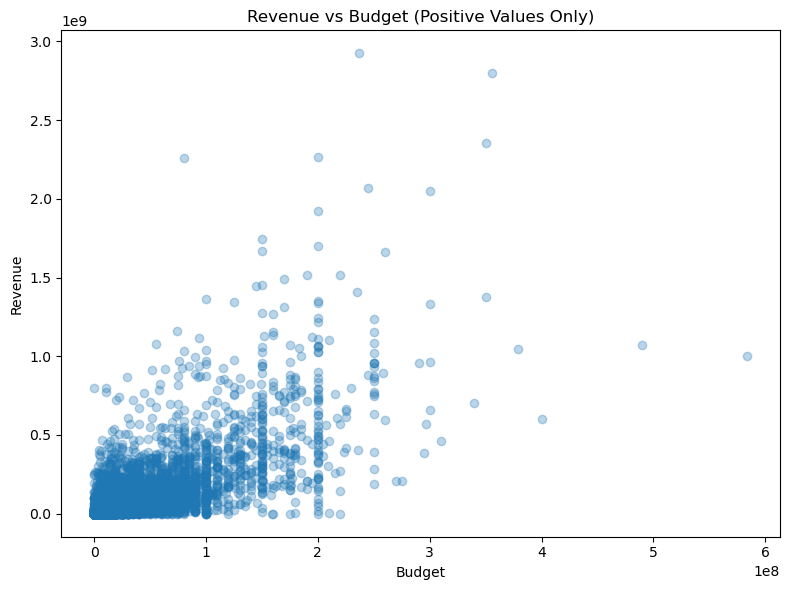

In [36]:
plot_df = df[["budget", "revenue"]].copy()
plot_df = plot_df.dropna()
plot_df = plot_df[(plot_df["budget"] > 0) & (plot_df["revenue"] > 0)]

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["budget"], plot_df["revenue"], alpha=0.3)
plt.title("Revenue vs Budget (Positive Values Only)")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

## <span style="color:blue">Q5 — Genre by Release Month (avg revenue + count)</span>

In [21]:
tracemalloc.start()
start = time.perf_counter()

# These lines ensure datetime + month
df_exploded["release_date"] = pd.to_datetime(df_exploded["release_date"], errors="coerce")
df_exploded["release_month"] = df_exploded["release_date"].dt.month

# I am making First table -- Average revenue per (genre, month)
q5_avg_pivot = (
    df_exploded
    .dropna(subset=["release_month"])
    .groupby(["genre", "release_month"])["revenue"]
    .mean()
    .unstack(fill_value=0)
)

# I am just renaming the  months to names for readability
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
q5_avg_pivot = q5_avg_pivot.rename(columns=month_map).round(0)

# I am making Second table - Counts per (genre, month) as a pivot
q5_count_pivot = (
    df_exploded
    .dropna(subset=["release_month"])
    .groupby(["genre", "release_month"])["revenue"]
    .size()
    .unstack(fill_value=0)
).rename(columns=month_map)

end = time.perf_counter()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Shoing the top genres by total movie count so the table isn't huge
top_genres = (
    df_exploded["genre"]
    .value_counts()
    .head(15)
    .index
)

display(q5_avg_pivot.loc[top_genres])
display(q5_count_pivot.loc[top_genres])

print(f"Execution Time: {end-start:.4f} sec")
print(f"Peak Memory: {peak/1e6:.2f} MB")

release_month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
genre,,,,,,,,,,,,
Drama,9862333.0,23492035.0,15586448.0,14963761.0,18553190.0,25804017.0,32173044.0,18210848.0,17684372.0,17193093.0,24266656.0,40584573.0
Comedy,20174112.0,34754695.0,30802828.0,22100455.0,38970171.0,65930521.0,48905396.0,20982096.0,20085130.0,22823434.0,43870806.0,41220206.0
Thriller,26660038.0,32604370.0,29637167.0,33497431.0,41784012.0,59251806.0,55513359.0,31660820.0,27258494.0,31484258.0,32011043.0,40980203.0
Action,43430515.0,53624820.0,63924991.0,83275393.0,121023465.0,120527292.0,103273614.0,42151399.0,40306050.0,50362332.0,59069908.0,104289172.0
Romance,11298907.0,27905481.0,23709454.0,25396714.0,30793215.0,34530878.0,37427543.0,20922273.0,16360991.0,20475144.0,30601641.0,46489830.0
Adventure,56210831.0,70100054.0,92060605.0,111506419.0,201802858.0,191082267.0,128099720.0,39377020.0,48223404.0,72054139.0,158454850.0,123046198.0
Crime,23919254.0,27658997.0,31089071.0,37462413.0,36282180.0,41940772.0,45044711.0,23620317.0,26194430.0,27446155.0,24136430.0,45528900.0
Horror,18236774.0,17076940.0,14637635.0,19140732.0,19996272.0,27095592.0,23109303.0,24495463.0,22947905.0,18951776.0,14541681.0,22332765.0
Family,37790591.0,54545355.0,81972993.0,45212779.0,121031560.0,171793388.0,60145045.0,26751119.0,42231019.0,51003951.0,116471770.0,59413031.0


release_month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
genre,,,,,,,,,,,,
Drama,796,817,950,830,847,798,689,945,1410,1285,1028,1098
Comedy,681,642,731,666,621,672,662,775,762,794,613,835
Thriller,334,355,387,375,342,327,353,460,539,541,338,341
Action,368,315,359,358,363,375,434,451,357,350,291,408
Romance,298,357,354,324,312,307,277,335,432,383,368,418
Adventure,201,207,272,225,202,266,293,286,215,247,229,370
Crime,222,217,250,257,206,242,215,294,335,312,219,240
Horror,230,185,197,223,206,189,224,279,278,396,197,149
Family,171,144,214,146,120,190,219,176,135,217,200,258


Execution Time: 0.1415 sec
Peak Memory: 88.21 MB


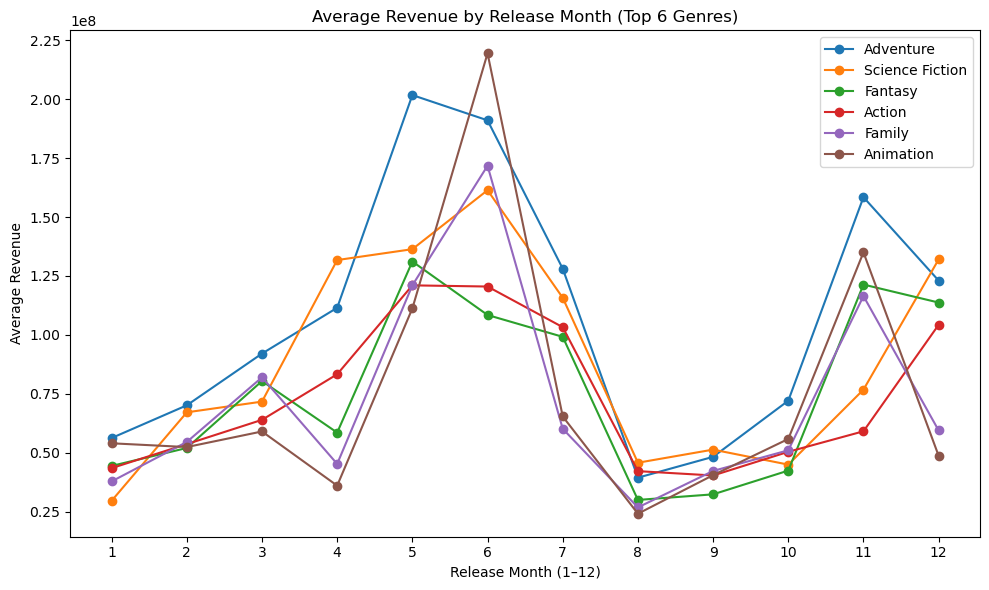

In [38]:
TOP_N = 6

if "release_date" not in df_exploded.columns:
    raise ValueError("Need 'release_date' column for Q5.")

tmp = df_exploded.dropna(subset=["release_date"]).copy()
tmp["month"] = tmp["release_date"].dt.month

top_genres = (
    tmp.groupby("genre")["revenue"]
    .mean()
    .sort_values(ascending=False)
    .head(TOP_N)
    .index
)

monthly = (
    tmp[tmp["genre"].isin(top_genres)]
    .groupby(["month", "genre"])["revenue"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
for g in top_genres:
    series = monthly[monthly["genre"] == g].sort_values("month")
    plt.plot(series["month"], series["revenue"], marker="o", label=g)

plt.title(f"Average Revenue by Release Month (Top {TOP_N} Genres)")
plt.xlabel("Release Month (1–12)")
plt.ylabel("Average Revenue")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()